<a href="https://colab.research.google.com/github/2023006766/deep-learning/blob/main/long_LSTM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

EPOCH: 100, Loss: 2.9532
EPOCH: 200, Loss: 0.5199
EPOCH: 300, Loss: 0.1364
EPOCH: 400, Loss: 0.0730
EPOCH: 500, Loss: 0.0493
EPOCH: 600, Loss: 0.0371
EPOCH: 700, Loss: 0.0297
EPOCH: 800, Loss: 0.0248
EPOCH: 900, Loss: 0.0213
EPOCH: 1000, Loss: 0.0186

Final Predictions:
Step 1: [0.   0.99 0.  ]
Step 2: [0.01 0.   0.99]
Step 3: [0.99 0.   0.  ]


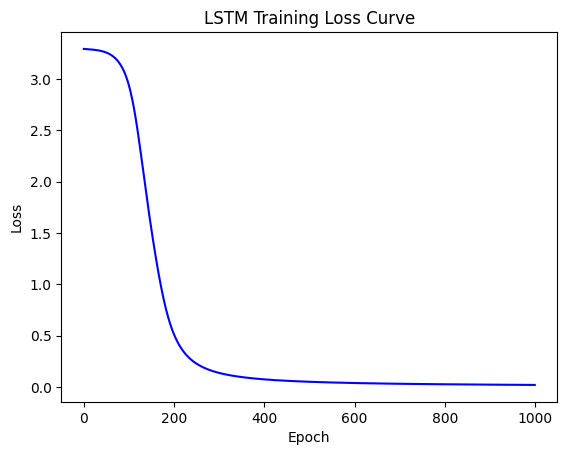

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Set print options for cleaner output
np.set_printoptions(suppress=True)

# 1. Activation and Loss Functions
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def softmax(x):
    exp_x = np.exp(x - np.max(x))
    return exp_x / np.sum(exp_x)

def cross_entropy(y_true, y_pred):
    return -np.sum(y_true * np.log(y_pred + 1e-12))

# 2. Dimensions and Initialization
input_size = 3
hidden_size = 2
output_size = 3

def init_gate():
    # Weights for gates: (hidden_size, input_size + hidden_size)
    return np.random.randn(hidden_size, input_size + hidden_size) * 0.1

wf = init_gate()  # Forget gate
wi = init_gate()  # Input gate
wo = init_gate()  # Output gate
wc = init_gate()  # Candidate gate

bf = np.zeros((hidden_size, 1))
bi = np.zeros((hidden_size, 1))
bo = np.zeros((hidden_size, 1))
bc = np.zeros((hidden_size, 1))

why = np.random.randn(output_size, hidden_size) * 0.1
by = np.zeros((output_size, 1))

# 3. Data Initialization
x1 = np.array([[1], [0], [0]])
x2 = np.array([[0], [1], [0]])
x3 = np.array([[0], [0], [1]])
inputs = [x1, x2, x3]

t1 = np.array([[0], [1], [0]])
t2 = np.array([[0], [0], [1]])
t3 = np.array([[1], [0], [0]])
targets = [t1, t2, t3]

learning_rate = 0.1
max_epochs = 1000
clip_value = 5
loss_history = []

# 4. Training Loop
for epoch in range(max_epochs):
    h = np.zeros((hidden_size, 1))
    c = np.zeros((hidden_size, 1))

    # Storage for BPTT
    hs, cs, zs = [h], [c], []
    fs, ins, os, c_tildes = [], [], [], []
    ps = []
    loss = 0

    # --- Forward Pass ---
    for t in range(3):
        # Concatenate hidden state and input
        z = np.vstack((h, inputs[t]))
        zs.append(z)

        f = sigmoid(np.dot(wf, z) + bf)
        i = sigmoid(np.dot(wi, z) + bi)
        o = sigmoid(np.dot(wo, z) + bo)
        c_tilde = np.tanh(np.dot(wc, z) + bc)

        c = f * c + i * c_tilde
        h = o * np.tanh(c)

        y = np.dot(why, h) + by
        p = softmax(y)

        # Append for backward pass
        fs.append(f)
        ins.append(i)
        os.append(o)
        c_tildes.append(c_tilde)
        hs.append(h)
        cs.append(c)
        ps.append(p)

        loss += cross_entropy(targets[t], p)

    loss_history.append(loss)

    # --- Backward Pass (BPTT) ---
    dwf, dwi, dwo, dwc = np.zeros_like(wf), np.zeros_like(wi), np.zeros_like(wo), np.zeros_like(wc)
    dbf, dbi, dbo, dbc = np.zeros_like(bf), np.zeros_like(bi), np.zeros_like(bo), np.zeros_like(bc)
    dwhy, dby = np.zeros_like(why), np.zeros_like(by)

    dh_next = np.zeros((hidden_size, 1))
    dc_next = np.zeros((hidden_size, 1))

    for t in reversed(range(3)):
        dy = ps[t] - targets[t]
        dwhy += np.dot(dy, hs[t+1].T)
        dby += dy

        dh = np.dot(why.T, dy) + dh_next
        do = dh * np.tanh(cs[t+1])
        do_raw = do * os[t] * (1 - os[t])

        # Gradient of cell state
        dc = dh * os[t] * (1 - np.tanh(cs[t+1])**2) + dc_next

        df = dc * cs[t]
        df_raw = df * fs[t] * (1 - fs[t])

        di = dc * c_tildes[t]
        di_raw = di * ins[t] * (1 - ins[t])

        dc_tilde = dc * ins[t]
        dc_tilde_raw = dc_tilde * (1 - c_tildes[t]**2)

        # Update gate weights/biases
        dwf += np.dot(df_raw, zs[t].T)
        dbf += df_raw
        dwi += np.dot(di_raw, zs[t].T)
        dbi += di_raw
        dwo += np.dot(do_raw, zs[t].T)
        dbo += do_raw
        dwc += np.dot(dc_tilde_raw, zs[t].T)
        dbc += dc_tilde_raw

        # Compute gradients for next timestep
        dz = np.dot(wf.T, df_raw) + np.dot(wi.T, di_raw) + np.dot(wo.T, do_raw) + np.dot(wc.T, dc_tilde_raw)
        dh_next = dz[:hidden_size, :]
        dc_next = fs[t] * dc

    # --- Gradient Clipping ---
    for grad in [dwf, dwi, dwo, dwc, dwhy, dbf, dbi, dbo, dbc, dby]:
        np.clip(grad, -clip_value, clip_value, out=grad)

    # --- Update Weights ---
    wf -= learning_rate * dwf
    wi -= learning_rate * dwi
    wo -= learning_rate * dwo
    wc -= learning_rate * dwc
    why -= learning_rate * dwhy
    bf -= learning_rate * dbf
    bi -= learning_rate * dbi
    bo -= learning_rate * dbo
    bc -= learning_rate * dbc
    by -= learning_rate * dby

    if (epoch + 1) % 100 == 0:
        print(f"EPOCH: {epoch+1}, Loss: {loss:.4f}")

# 5. Final Output & Plotting
print("\nFinal Predictions:")
for t in range(3):
    print(f"Step {t+1}: {np.round(ps[t], 2).flatten()}")

plt.plot(loss_history, color='blue')
plt.title("LSTM Training Loss Curve")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()